Problem with DT(Decision Tress):
1. Overfitting
2. Takes too long to train


So , we do feature training.

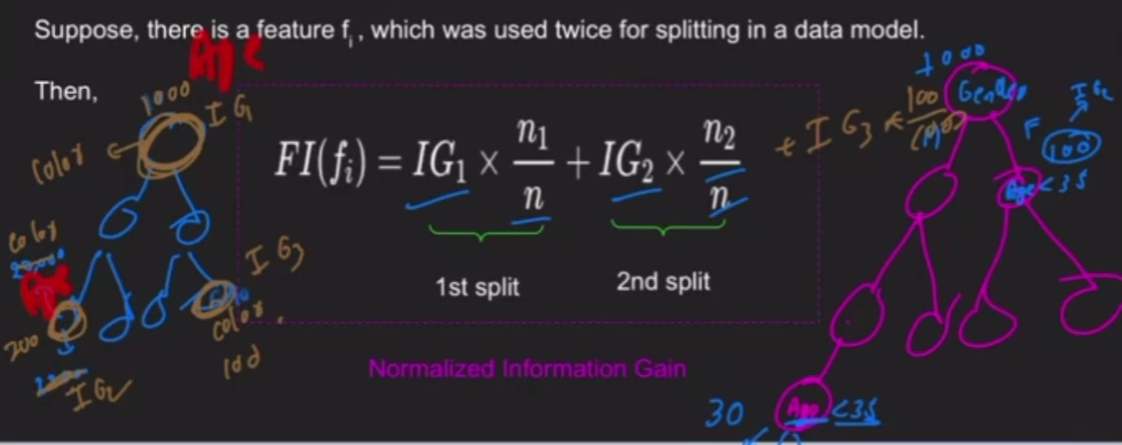

FI --> Feature Importance

Since we can calculate IG for any node, we take the weighted IG's as the FI value for that feature

In [6]:
import pandas as pd
import pickle
import numpy as np

with open('preprocessed_X_sm.pickle', 'rb') as handle:
    # X_train = pickle.load(handle)
    X_train = pd.read_pickle("preprocessed_X_sm.pickle")

with open('X_test.pickle', 'rb') as handle:
    # X_test = pickle.load(handle)
    X_test = pd.read_pickle("X_test.pickle")


with open('y_sm.pickle', 'rb') as handle:
    # y_train = pickle.load(handle)
    y_train = pd.read_pickle("y_sm.pickle")


with open('y_test.pickle', 'rb') as handle:
    # y_test = pickle.load(handle)
    y_test = pd.read_pickle("y_test.pickle")

In [7]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=7, max_depth=4)
tree_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# **Bagging and Random Forest**

- Ensemble techniques:

    - Why do we need to take only one person's opinion , why not take multiple people's opinion?
    - This is where Ensemble techniques come into play.

    - Ensemble techniques combine multiple models to make a final prediction.

    - Take a data set, train it on multiple models and then combine their predictions to make a final prediction.
    
        - For example labels are 0 and 1 and there are 5 models.
        - If 3 models predict 0 and 2 models predict 1 then the final prediction will be 0.
        - This is called majority voting.
    
    - This gives more confidence in the prediction.

- There are different Ensemble techniques, one of them is Bagging.
    - Bagging is also called Bootstrap Aggregation.
    - Train different models on the same task and combine their prediction smartly.


**Also called as Random Forest**

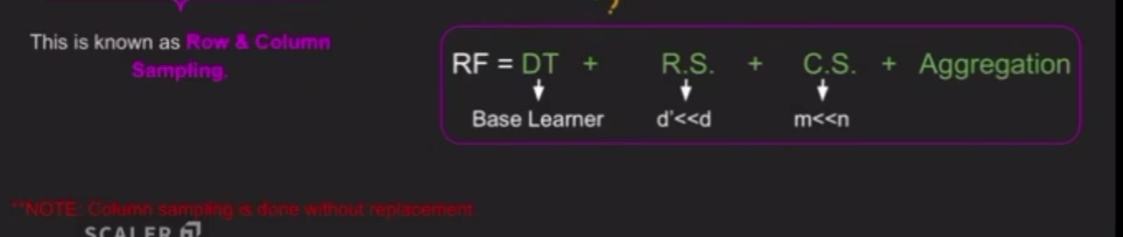

- In a data set, take some random columns and random rows.
- Train a model on this data.
- Do this multiple times.
- Take the average/aggregation of all the models.

- R.S means very few rows 
- C.S means very few columns 


- To learn:
    - KFold technique
    - Cross validation 

- Grid Search CV
    - One of the best hyperparameter optimization technique

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

# need 5 trees
reg = RandomForestRegressor(n_estimators=5)
params = {
          'n_estimators' : [100,200,300,400],
          'max_depth' : [3,5,10],
          'criterion' : ['gini', 'entropy'],
          'bootstrap' : [True, False],
          'max_features' : [8,9,10]
         }

Instead of writing for loop for each of the parametre to find the best technique, we can use GridSearchCV

In [4]:

from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(estimator = RandomForestClassifier(), 
                    param_grid=params, 
                    scoring = 'accuracy',
                    cv = 5,
                    n_jobs = -1)

In [13]:
grid.fit(X_train, y_train)

print("Best Parameters: ", grid.best_params_)
print("Best Score: ", grid.best_score_)

Best Parameters:  {'bootstrap': False, 'criterion': 'gini', 'max_depth': 10, 'max_features': 9, 'n_estimators': 400}
Best Score:  0.9086193510583754


In [33]:
#Write subsample function
import numpy as np
import random

def subsample(dataset, ratio=1.0):
    dataset = np.array(dataset)
    n_sample = round(len(dataset) * ratio)
    indices = np.random.choice(len(dataset), n_sample, replace=True)
    return dataset[indices]

def build_tree(sample, max_depth):
    tree = DecisionTreeClassifier(max_depth=max_depth)
    sample = np.array(sample)
    X, y = sample[:, :-1], sample[:, -1]
    tree.fit(X, y)
    return tree

def bagging_predict(trees, row):
    predictions = [tree.predict(row.reshape(1,-1))[0] for tree in trees]
    return max(set(predictions), key=predictions.count)

def bagging(train, test, max_depth, n_trees, ratio):
	trees = list()
	for i in range(n_trees):
		sample = subsample(train, ratio) #A sample created from dataset of size round(len(dataset) * ratio)
		tree = build_tree(sample, max_depth)
		trees.append(tree)
	
	#store the predictions for each observation in the test data
	predictions = [tree.predict(test) for tree in trees]
	return(predictions)


In [34]:
train = [[-0.049754741299329164, 1.7545324153602802, -2.015451904277496, -0.6655946053274271, 1.7654623717757776, 0.0], [-0.870176558754425, -0.8632506160200222, 1.0363347961933609, -0.9921482916137182, -1.1832955643653762, 1.0], [-0.5129465077761397, -1.2734979390270784, 1.0392261463425687, 0.5032338839619092, -0.27021541668479643, 1.0], [-1.1259555456220574, -1.3824926465371696, -2.4659947360738013, -1.0063448217690898, 0.5301098720856643, 0.0], [1.3355396455376942, 0.4767704351913865, -0.30995179013581164, 0.47754374871627314, 1.0282482787129177, 0.0], [-0.7941311111136664, -0.888479087765921, -0.9250860232848708, 1.7103333917320582, -0.006363196215441307, 0.0], [0.9640563948034004, 1.4206857618787228, -1.6719701692403608, -0.3025879352391404, -0.3062031013690185, 0.0], [2.1330018022897006, -0.2530885153742814, 0.14824433392167236, -1.5377998003498103, 1.491748723938095, 0.0], [0.8568323473193591, 1.454906042604595, 1.0226070656111748, 1.4208697842258664, -0.27155848114641123, 1.0], [-1.1103222963405424, -0.13362863845048603, 0.5522979973275985, 0.42165872702810914, 0.4884106152343072, 0.0]]
test = [[0.17633958605089237, 0.35362499501406774, 1.0412089882932318, -0.7965536407430361, 0.9519863722017938], [0.620158792718217, 1.7453802356037476, 0.2816748822184669, -0.9782700792376439, -0.7872827938664166], [-1.306157556172553, -0.36060622411280663, 0.9397657677158866, -0.1262661498810779, -0.458138342833524], [-1.3391549838490366, 0.9327917466845197, 1.1026267285716564, 0.23785062696034148, -0.4146697234931255], [0.08239261344402903, 0.6390284651763855, 0.9943395785869232, -1.5238363086071611, -0.5068234330383359], [1.2456200894224607, -1.2782333788330993, -0.9217918528513316, 1.6251354644171232, -0.6064346799018023], [-0.2632339135609847, -1.086878071181507, -1.7763680131285988, 0.4366870243082978, 1.7860028809138975], [-0.9190320708567004, 0.6107324610184034, 0.9930674674619598, 1.353023555031771, -1.800699232148709], [0.9540368382685985, -1.227571715875412, -0.18990171035397174, -0.5446964612387463, 0.3511497213610034], [1.8860175589060588, -0.036958602806592036, -1.2247513223969646, 0.7340332381471137, 1.1319547973555735]]
max_depth = 1
n_trees = 3
ratio = 0.1

print(bagging(train, test, max_depth, n_trees, ratio))

[array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])]


In [24]:
train = np.array(train)
test = np.array(test)